In [1]:
import time

import numpy as np

from scipy import special, integrate, spatial, stats

import sympy
from sympy.printing.numpy import SciPyPrinter

from astropy import units as u

In [2]:
from matplotlib import pyplot as plt 

In [3]:
import nautilus 
import corner

Helper functions from [circular_sersic_with_green_integral.ipynb](circular_sersic_with_green_integral.ipynb)

In [4]:
BN_ICOEFFS = [2, -1/3, 4/405, 46/25515, 131/1148175, -2194697/30690717750]

def f_bn(n):
    """
    Ciotti and Bertin 99, valid for n >~ 0.36
    """
    return np.sum([C*n**(1-i) for i, C in enumerate(BN_ICOEFFS)], axis=0)

def sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return Ie * np.exp(-bn*((R/Re)**(1/n)-1))

def log_sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return np.log(Ie) - bn*((R/Re)**(1/n)-1)

In [5]:
def sersic_distribution(U, Re, n, Router=np.inf):
    bn = f_bn(n)

    Iemax = 1/finteg(Router, Re, n, bn, 1)

    sympy_gamma = U*bn**(2*n)*np.exp(-bn)/(Iemax*Re**2*n)
    gamma_arg = special.gammaincinv(2*n, sympy_gamma / special.gamma(2*n))
    return Re*(gamma_arg/bn)**n


In [6]:
def sersic_plus_uniform_circle(ntotal, fbkg, n, Re=1, Router=10, polar_out=True):
    nbkg = int(ntotal*fbkg)
    nfg = ntotal - nbkg

    r_bkg = np.sqrt(np.random.rand(nbkg))*Router
    θ_bkg = np.random.rand(nbkg)*2*np.pi

    r_fg = sersic_distribution(np.random.rand(nfg), Re, n, Router)
    θ_fg = np.random.rand(nfg)*2*np.pi

    r, θ = np.concatenate([r_fg, r_bkg]), np.concatenate([θ_fg, θ_bkg])

    if polar_out:
        return r, θ, nfg
    else:
        x = r*np.cos(θ)
        y = r*np.sin(θ)
        return x, y, nfg


In [7]:
def dimensionless_path_integrand(x, y, Δx, Δy, Re, n):
    bn = f_bn(n)
    Rsq = x*x + y*y
    twon = 2*n
    segments = Re**2*bn**(-twon)*n*(x*Δy - y*Δx)*np.exp(bn)*special.gamma(twon)*special.gammainc(twon, Re**(-1/n)*bn*Rsq**(1/twon))/Rsq
    return np.sum(segments)

def sersic_integrate_hull(hull, n_per_segment, n, Re):
    vertxys = hull.points[hull.vertices].T
    edgexys = np.linspace(vertxys, np.roll(vertxys,-1, axis=-1), n_per_segment).T
    integral_of_segments = [dimensionless_path_integrand(x, y, x[1]-x[0], y[1]-y[0], Re=Re, n=n) for x,y in edgexys]
    return np.sum(integral_of_segments)

In [8]:
def finteg(x, Re, n, bn, Ie):
    return Ie*Re**2*bn**(-2*n)*n*np.exp(bn)*special.gamma(2*n)*special.gammainc(2*n, Re**(-1/n)*bn*x**(n**(-1.0)))

# Very simplified two-plateau case

In [ ]:
prior = nautilus.Prior()

prior.add_parameter('x0', (-2, 2))
prior.add_parameter('y0', (-2, 2))
prior.add_parameter('Rbreak', (0.1, 2))
prior.add_parameter('fbkg', (0.1, 0.9))

def loglikes(param_dict, data, n_per_segment=1000):
    x0 = param_dict['x0']
    y0 = param_dict['y0']
    Rbreak = param_dict['Rbreak']
    fbkg = param_dict['fbkg']
    
    r = np.hypot(data[0]-x0, data[1]-y0)

    logfg = np.log(1-fbkg) -  np.log(Rbreak**2*2*np.pi)
    logfg = logfg * np.ones_like(r)
    logfg[r>Rbreak] = -np.inf

    logbg = np.log(fbkg) -  np.log(np.max(r)**2*2*np.pi)

    return np.logaddexp(logfg, logbg)

def loglike(*args, **kwargs):
    return np.sum(loglikes(*args, **kwargs))


nall = 1000
fbkg = .5
Router = 5
Rbreak = 1

bkgr = np.sqrt(np.random.rand(int(fbkg*nall)))*Router
fgr = np.sqrt(np.random.rand(int((1-fbkg)*nall)))*Rbreak
rall = np.concatenate((fgr, bkgr))
theta = np.random.rand(len(bkgr) + len(fgr))*2*np.pi

x = rall * np.cos(theta)
y = rall * np.sin(theta)

sampler = nautilus.Sampler(prior, loglike, n_live=1000, likelihood_kwargs=dict(data=(x, y)), pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


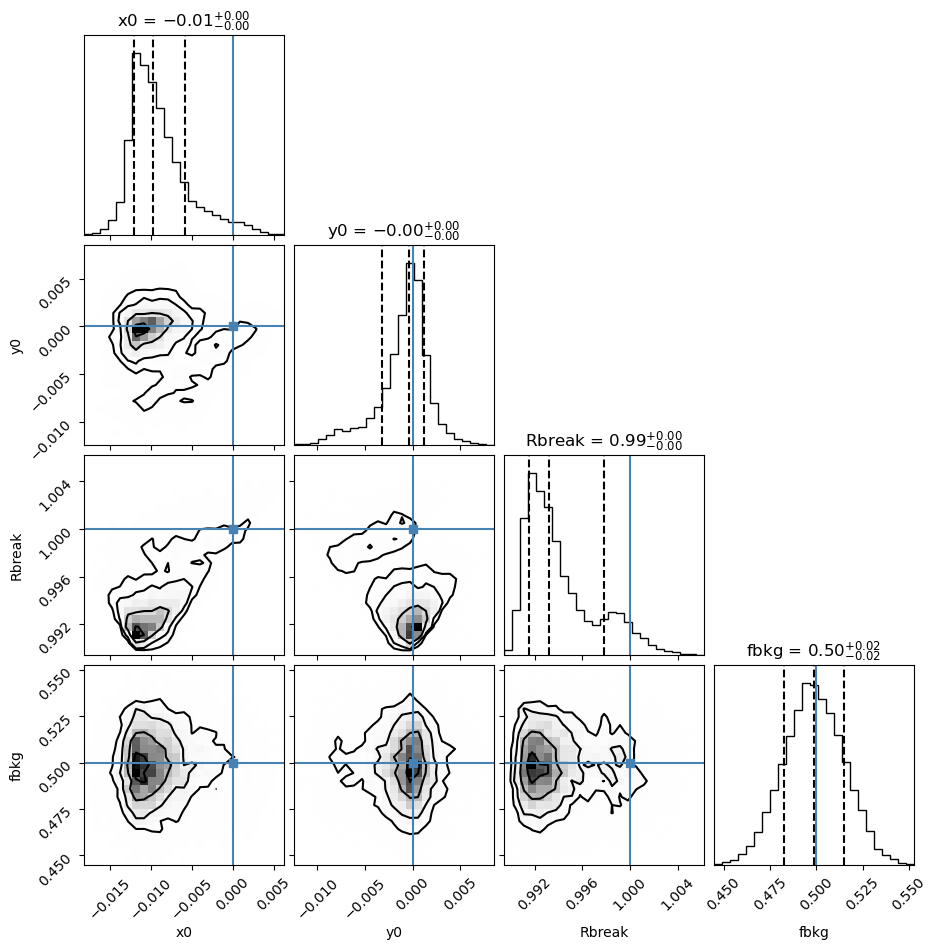

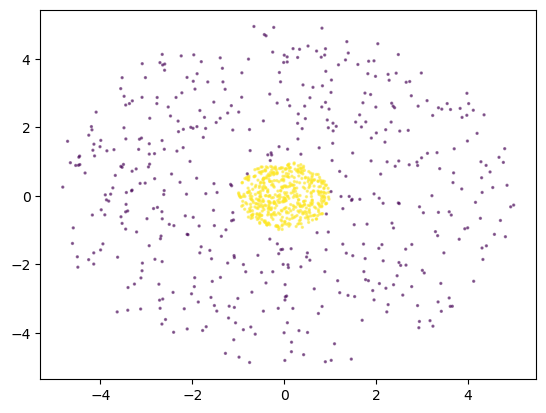

In [ ]:

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=25, labels=prior.keys,
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=[0, 0, Rbreak, fbkg])

plt.figure()
plt.scatter(x, y, c=loglikes(dict(x0=0, y0=0, Rbreak=1, fbkg=.5),data=(x, y)), s=2, alpha=.5);

That's working, so at least the core concept is sound...